In [12]:
# Loading the data 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define the raw data URL
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"

# Load the data using the semicolon separator (sep=";")so data is not in one column

df = pd.read_csv(url, sep=";")

# Rename the target column from 'quality' to 'label'to match instructions

df = df.rename(columns={'quality': 'label'})

# Map raw scores to project categories (0, 1, 2)
# Low (0): scores 3-4 | Medium (1): scores 5-6 | High (2): scores 7-8
df['label'] = df['label'].map({3: 0, 4: 0, 5: 1, 6: 1, 7: 2, 8: 2})

# Show the results
print("Columns found:", df.columns.tolist())
df.head()

Columns found: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'label']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1


In [13]:
#Preprocessing - splitting and scaling the data

# Separate features (X) from the target label (y)
# drop 'label' to create X, and keep only 'label' for y
X = df.drop("label", axis=1)
y = df["label"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Show results: Display the shape of the new sets
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (1279, 11)
Testing features shape: (320, 11)


In [14]:
# Train the KNN Model

# Create the KNN model instance (starting with k=5)
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model using the scaled training data
knn.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test_scaled)

# Show results: Print the accuracy score
print(f"Initial Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Initial Model Accuracy: 0.84


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.87      0.95      0.91       262
           2       0.65      0.43      0.51        47

    accuracy                           0.84       320
   macro avg       0.50      0.46      0.47       320
weighted avg       0.81      0.84      0.82       320



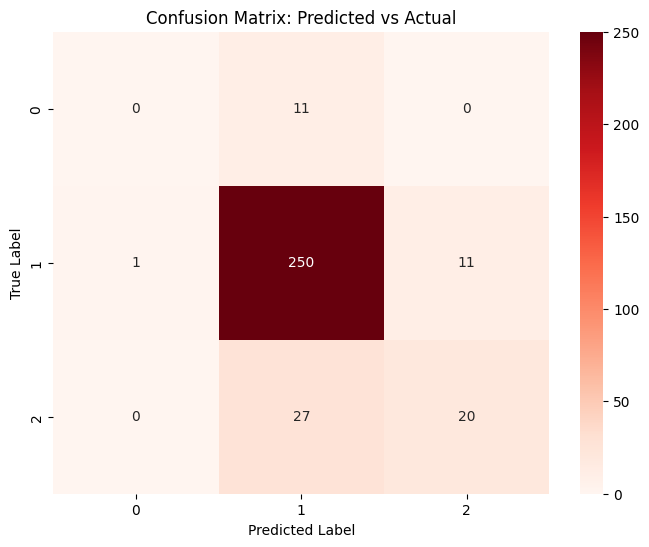

In [15]:
# Evaluate the model for mistakes

# Generate the Confusion Matrix to see mistakes
cm = confusion_matrix(y_test, y_pred)

# Print a detailed Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix with a heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

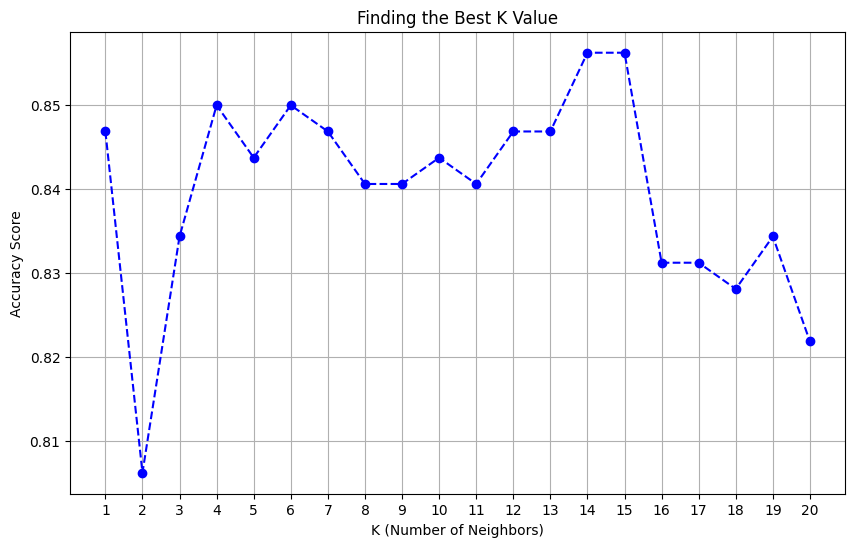

The best accuracy is 0.86 at K = 14


In [16]:
# Optimization - Finding the best K value

# Create a list to store accuracy results
accuracies = []
k_range = range(1, 21)

# Loop through k=1 to k=20
for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    accuracies.append(model.score(X_test_scaled, y_test))

# Plot Accuracy vs K Value
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='blue')
plt.title('Finding the Best K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Print the best performing K
best_k = k_range[accuracies.index(max(accuracies))]
print(f"The best accuracy is {max(accuracies):.2f} at K = {best_k}")

In [ ]:
# Sommelier Prediction Function

def predict_wine_quality(features):
    # Scale the input list using the same scaler from Cell 2 - use [[ ]] to make it a 2D array
    features_scaled = scaler.transform([features])
    
    # Use the trained model to predict the class
    prediction = knn.predict(features_scaled)[0]
    
    # Map the numerical result to a text description
    quality_map = {0: "Low", 1: "Medium", 2: "High"}
    
    result = quality_map.get(prediction, "Unknown")
    return f"This wine is likely of {result} quality 🍷"

# Test the function with the sample data provided
sample = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
print(predict_wine_quality(sample))

This wine is likely of Medium quality 🍷


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Hyperparameter tuning

# Use the 'best_k' found in the previous step 
final_knn = KNeighborsClassifier(n_neighbors=best_k)

# Re-train the model on the full scaled training set
final_knn.fit(X_train_scaled, y_train)

# Final performance check
final_accuracy = final_knn.score(X_test_scaled, y_test)
print(f"Final Optimized Accuracy with K={best_k}: {final_accuracy:.2%}")

Final Optimized Accuracy with K=14: 85.62%
